# Pixel-Wise Classification: A Generalizable Approach to Image Segmentation

**Author:** Aman Sharma  
**Date:** April 2026

## Project Overview

**Image segmentation** is a computer vision technique in which each pixel of an image is assigned to a specific category. All pixels belonging to objects from the same category are assigned an identical label, resulting in a segmentation mask where each unique label corresponds to a distinct class ID.

While the **Cityscapes dataset** is a common benchmark for this task, the present project utilizes the **FashionMNIST dataset**. This dataset contains images of models wearing various clothing items, accompanied by a separate file containing the corresponding ground-truth masks.

Importantly, the project is designed to be **generalizable** and can be easily adapted to any other image segmentation dataset with minimal modifications.

---

### Key Concepts

| Concept | Description |
|---------|-------------|
| Pixel-level classification | Every pixel receives a category label |
| Segmentation mask | Output map where each label ID represents a class |
| FashionMNIST | Clothing item images with associated masks |
| Generalizability | Framework can be extended to other datasets |


**Labels:** 0=null, 1=accessories, 2=bag, 3=belt, 4=blazer, 5=blouse, 6=bodysuit, 7=boots, 8=bra, 9=bracelet, 10=cape, 11=cardigan, 12=clogs, 13=coat, 14=dress, 15=earrings, 16=flats, 17=glasses, 18=gloves, 19=hair, 20=hat, 21=heels, 22=hoodie, 23=intimate, 24=jacket, 25=jeans, 26=jumper, 27=leggings, 28=loafers, 29=necklace, 30=panties, 31=pants, 32=pumps, 33=purse, 34=ring, 35=romper, 36=sandals, 37=scarf, 38=shirt, 39=shoes, 40=shorts, 41=skin, 42=skirt, 43=sneakers, 44=socks, 45=stockings, 46=suit, 47=sunglasses, 48=sweater, 49=sweatshirt
 

In [ ]:
pip install -q kaggle

In [ ]:
!mkdir ~/.kaggle


mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [3]:
import kagglehub
path = kagglehub.dataset_download("rajkumarl/people-clothing-segmentation")

In [4]:
import shutil

# Define where you want it
target_dir = "/kaggle/working/people-clothing-segmentation"

# Copy entire dataset
shutil.copytree(path, target_dir, dirs_exist_ok=True)

print(f"Dataset copied to: {target_dir}")

Dataset copied to: /kaggle/working/people-clothing-segmentation


In [9]:
import os
os.makedirs('/kaggle/working/people-clothing-segmentation/train/images', exist_ok=True)
os.makedirs('/kaggle/working/people-clothing-segmentation/train/masks', exist_ok=True)
os.makedirs('/kaggle/working/people-clothing-segmentation/val/images', exist_ok=True)
os.makedirs('/kaggle/working/people-clothing-segmentation/val/masks', exist_ok=True)
os.makedirs('/kaggle/working/people-clothing-segmentation/model', exist_ok=True)


In [10]:
traindir= "/kaggle/working/people-clothing-segmentation/train/"
valdir= "/kaggle/working/people-clothing-segmentation/val/"



In [11]:
vallist=["0115","0025","0010","0003","0125","0200","0515","0225","0805","0915","0630","0301","0112","0905","0823","0527","0088","0055","0018",
          "0222","0049","0273","0299","0282","0372","0027","0445","0582","0374","0956","0211","0019","0961","0397","0699","0789","0996","0290",
          "0110","0315","0335","0419","0666","0525","0927","0555","0275","0855","0815","0130","0371","0412","0105","0423","0507","0028","0035","0118",
          "0232","0849","0673","0688","0777","0472","0991","0485","0592","0334","0827","0651","0619","0567","0393","0609","0719","0916","0190",
          ]

# Convert vallist to integers for comparison
vallist_int = {int(num) for num in vallist}


result = []
for i in range(1, 1001):
    if i not in vallist_int:
        result.append(f"{i:04d}")

trainlist = result

In [12]:
for i in vallist:
   shutil.copy2("/kaggle/working/people-clothing-segmentation/png_images/IMAGES/img_"+i +".png" , valdir+"images/img_" +i +".png")
   shutil.copy2("/kaggle/working/people-clothing-segmentation/png_masks/MASKS/seg_"+i +".png", valdir+"masks/seg_" +i +".png")

for i in trainlist:
   shutil.copy2("/kaggle/working/people-clothing-segmentation/png_images/IMAGES/img_"+i +".png", traindir+ "images/img_" +i +".png")
   shutil.copy2("/kaggle/working/people-clothing-segmentation/png_masks/MASKS/seg_"+i +".png", traindir +"masks/seg_" +i +".png")

In [13]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A

mean = [123.675, 116.28, 103.53]
std  = [58.395,  57.12,  57.375]

H,W =512,512

transform = A.Compose([
    A.RandomCrop(H, W, p=1),
    A.HorizontalFlip(p=0.3),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.Transpose(p=0.3),
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.1),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_limit=(1, 2),
               shadow_dimension=5, p=0.1),
    A.RandomBrightnessContrast(p=0.2)
])

valtransform = A.Compose([A.Resize(H, W)])


class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, augment_fn):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.augment_fn  = augment_fn

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"), dtype=np.float32)
        mask  = np.array(Image.open(self.mask_paths[idx]).convert("L"),   dtype=np.int64)

        # Normalize (same as your TF preprocess)
        image = (image - mean) / std

        # Albumentations expects uint8 for some transforms, so we pass mask as-is
        augmented = self.augment_fn(image=image.astype(np.float32), mask=mask.astype(np.float32))
        image = augmented["image"]
        mask  = augmented["mask"].astype(np.int64)

        # HWC → CHW for PyTorch
        image = np.transpose(image, (2, 0, 1))

        return {
            "pixel_values": torch.tensor(image, dtype=torch.float32),
            "labels":       torch.tensor(mask,  dtype=torch.long)
        }

In [14]:
import os

batchsize = 2

# Filter to only paths that actually exist on disk
train_image_paths = [traindir + "images/img_" + i + ".png" for i in trainlist]
train_mask_paths  = [traindir + "masks/seg_"  + i + ".png" for i in trainlist]

val_image_paths   = [valdir + "images/img_" + i + ".png" for i in vallist]
val_mask_paths    = [valdir + "masks/seg_"  + i + ".png" for i in vallist]

# Filter out missing files
train_pairs = [(img, msk) for img, msk in zip(train_image_paths, train_mask_paths)
               if os.path.exists(img) and os.path.exists(msk)]
val_pairs   = [(img, msk) for img, msk in zip(val_image_paths, val_mask_paths)
               if os.path.exists(img) and os.path.exists(msk)]

train_image_paths, train_mask_paths = zip(*train_pairs)
val_image_paths,   val_mask_paths   = zip(*val_pairs)

print(f"Train samples: {len(train_image_paths)}")  # will show actual count
print(f"Val samples:   {len(val_image_paths)}")

traindata1 = DataLoader(
    SegmentationDataset(train_image_paths, train_mask_paths, transform),
    batch_size=batchsize,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valdata1 = DataLoader(
    SegmentationDataset(val_image_paths, val_mask_paths, valtransform),
    batch_size=batchsize,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Train samples: 923
Val samples:   77


In [15]:
batch = next(iter(valdata1))
print(batch)

{'pixel_values': tensor([[[[ 0.1426,  0.1426,  0.1435,  ...,  0.1500,  0.1478,  0.1428],
          [ 0.1426,  0.1426,  0.1457,  ...,  0.1626,  0.1597,  0.1583],
          [ 0.1597,  0.1607,  0.1702,  ...,  0.1629,  0.1597,  0.1519],
          ...,
          [ 1.4882,  1.5658,  1.5837,  ...,  1.7266,  1.6490,  1.5745],
          [ 1.6192,  1.6481,  1.6479,  ...,  1.7481,  1.7160,  1.6821],
          [ 1.6003,  1.5507,  1.5163,  ...,  1.6667,  1.6409,  1.6262]],

         [[ 0.6078,  0.6078,  0.6088,  ...,  0.6855,  0.6832,  0.6781],
          [ 0.6078,  0.6078,  0.6111,  ...,  0.6984,  0.6954,  0.6940],
          [ 0.6254,  0.6264,  0.6361,  ...,  0.6986,  0.6954,  0.6874],
          ...,
          [ 1.6334,  1.7127,  1.7310,  ...,  1.8946,  1.8153,  1.7391],
          [ 1.7673,  1.7969,  1.7966,  ...,  1.9166,  1.8838,  1.8491],
          [ 1.7479,  1.6973,  1.6621,  ...,  1.8333,  1.8070,  1.7920]],

         [[ 1.5245,  1.5245,  1.5255,  ...,  1.6193,  1.6170,  1.6119],
          [ 1

In [16]:
batch = next(iter(valdata1))
print(batch["pixel_values"].shape, batch["labels"].shape)

torch.Size([2, 3, 512, 512]) torch.Size([2, 512, 512])


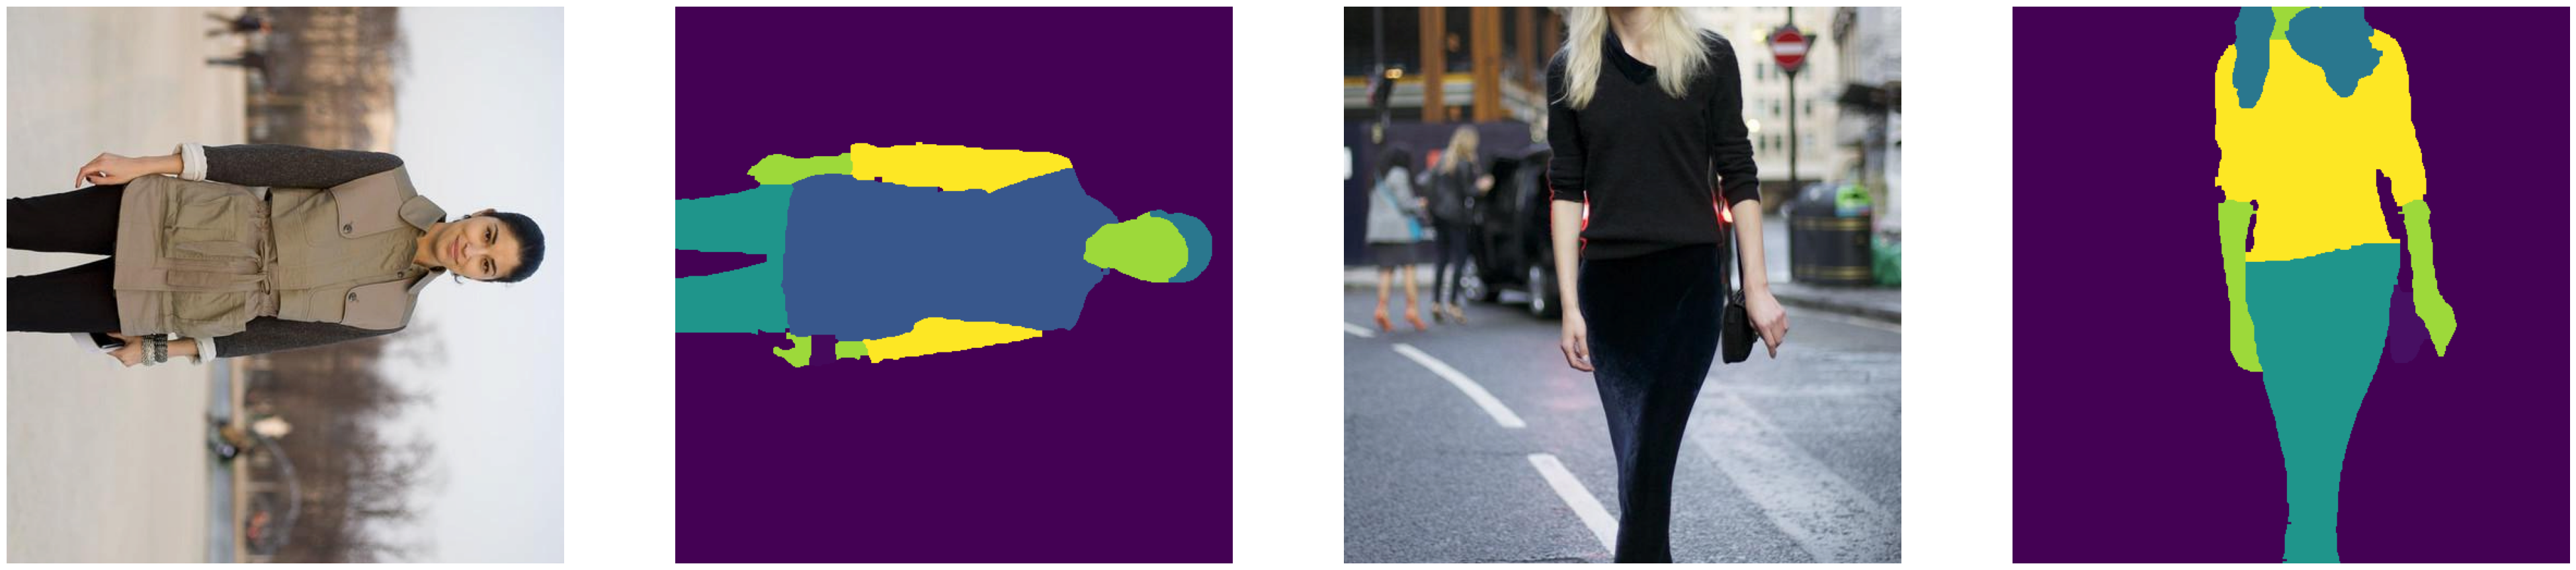

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(50, 50))

batch = next(iter(traindata1))
images = batch["pixel_values"]
labels = batch["labels"]

for i in range(batchsize * 2):
    ax = plt.subplot(1, batchsize * 2, i + 1)

    if i % 2 == 0:
        # CHW → HWC for matplotlib, and denormalize for proper visualization
        img = images[i // 2].permute(1, 2, 0).numpy()
        img = (img * std) + mean          # denormalize
        img = np.clip(img, 0, 255).astype(np.uint8)
        plt.imshow(img)

    else:
        plt.imshow(labels[i // 2].numpy())

    plt.axis("off")

plt.show()

In [18]:
import pandas as pd
df = pd.read_csv("/kaggle/working/people-clothing-segmentation/labels.csv")

id2label = {}

for i,j in df.iterrows():
  if i ==0:
    id2label[i] = "nan"

  else:
    id2label[i] = j["label_list"]

label2id = {label : id for id,label in id2label.items()}



In [19]:
!pip install evaluate transformers[torch] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00


In [20]:
from transformers import SegformerForSemanticSegmentation
import torch

modelid = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
model = SegformerForSemanticSegmentation.from_pretrained(
    modelid,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Verify model output shape
import torch
dummy = torch.zeros([1, 3, 512, 512])
print(model(dummy).logits.shape)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/339M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b5-finetuned-cityscapes-1024-1024
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([19]) vs model:torch.Size([59])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([19, 768, 1, 1]) vs model:torch.Size([59, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


torch.Size([1, 59, 128, 128])


In [24]:
import evaluate
import numpy as np

metric = evaluate.load("mean_iou")
def computemetrics(eval_pred):
    logits, labels = eval_pred
    
    # Handle GPU tensors
    if isinstance(logits, torch.Tensor):
        logits = logits.detach().cpu()
        labels = labels.cpu()
    else:
        logits = torch.from_numpy(logits)
        labels = torch.from_numpy(labels)
    
    # Resize logits
    upsampled = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False
    )
    
    predlabs = upsampled.argmax(dim=1).numpy()
    labels_np = labels.numpy()
    
    # Compute metrics
    metrics = metric.compute(
        predictions=predlabs,
        references=labels_np,
        num_labels=len(label2id),
        ignore_index=255
    )
    
    # Add per-class metrics
    precatacc = metrics.pop("per_category_accuracy").tolist()
    percatiou = metrics.pop("per_category_iou").tolist()
    
    for i, (acc, iou) in enumerate(zip(precatacc, percatiou)):
        class_name = id2label.get(i, f"class_{i}")
        metrics[f"accuracy_{class_name}"] = acc
        metrics[f"iou_{class_name}"] = iou
    
    return {f"val_{k}": v for k, v in metrics.items()}

In [25]:
import torch

# Check if CUDA (GPU) is available
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Alternative: run nvidia-smi to see detailed GPU info
!nvidia-smi


CUDA available: True
Number of GPUs: 2
GPU Name: Tesla T4
Tue Apr  7 08:13:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |              

In [ ]:
from transformers import TrainingArguments, Trainer

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

train_dataset = SegmentationDataset(train_image_paths, train_mask_paths, transform)
val_dataset   = SegmentationDataset(val_image_paths,   val_mask_paths,   valtransform)

# Verify single sample shapes BEFORE creating Trainer
print(len(train_dataset))                          # should be 923
print(train_dataset[0]["pixel_values"].shape)      # should be (3, 512, 512)
print(train_dataset[0]["labels"].shape)            # should be (512, 512)

from transformers import TrainingArguments, Trainer

batchsize = 2
nepochs = 15
learnrt = 6e-5
wdecay = 0.01

training_args = TrainingArguments(
    output_dir="./segformer-finetuned",
    num_train_epochs=nepochs,
    per_device_train_batch_size=batchsize,
    per_device_eval_batch_size=batchsize,
    learning_rate=learnrt,
    weight_decay=wdecay,
    warmup_steps=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    remove_unused_columns=False,
)


def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels       = torch.stack([item["labels"]       for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}



trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=computemetrics,
    data_collator=collate_fn,
)


trainer.train()

Using device: cuda
923
torch.Size([3, 512, 512])
torch.Size([512, 512])


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Val Mean Iou,Val Mean Accuracy,Val Overall Accuracy,Val Accuracy Nan,Val Iou Nan,Val Accuracy Accessories,Val Iou Accessories,Val Accuracy Bag,Val Iou Bag,Val Accuracy Belt,Val Iou Belt,Val Accuracy Blazer,Val Iou Blazer,Val Accuracy Blouse,Val Iou Blouse,Val Accuracy Bodysuit,Val Iou Bodysuit,Val Accuracy Boots,Val Iou Boots,Val Accuracy Bra,Val Iou Bra,Val Accuracy Bracelet,Val Iou Bracelet,Val Accuracy Cape,Val Iou Cape,Val Accuracy Cardigan,Val Iou Cardigan,Val Accuracy Clogs,Val Iou Clogs,Val Accuracy Coat,Val Iou Coat,Val Accuracy Dress,Val Iou Dress,Val Accuracy Earrings,Val Iou Earrings,Val Accuracy Flats,Val Iou Flats,Val Accuracy Glasses,Val Iou Glasses,Val Accuracy Gloves,Val Iou Gloves,Val Accuracy Hair,Val Iou Hair,Val Accuracy Hat,Val Iou Hat,Val Accuracy Heels,Val Iou Heels,Val Accuracy Hoodie,Val Iou Hoodie,Val Accuracy Intimate,Val Iou Intimate,Val Accuracy Jacket,Val Iou Jacket,Val Accuracy Jeans,Val Iou Jeans,Val Accuracy Jumper,Val Iou Jumper,Val Accuracy Leggings,Val Iou Leggings,Val Accuracy Loafers,Val Iou Loafers,Val Accuracy Necklace,Val Iou Necklace,Val Accuracy Panties,Val Iou Panties,Val Accuracy Pants,Val Iou Pants,Val Accuracy Pumps,Val Iou Pumps,Val Accuracy Purse,Val Iou Purse,Val Accuracy Ring,Val Iou Ring,Val Accuracy Romper,Val Iou Romper,Val Accuracy Sandals,Val Iou Sandals,Val Accuracy Scarf,Val Iou Scarf,Val Accuracy Shirt,Val Iou Shirt,Val Accuracy Shoes,Val Iou Shoes,Val Accuracy Shorts,Val Iou Shorts,Val Accuracy Skin,Val Iou Skin,Val Accuracy Skirt,Val Iou Skirt,Val Accuracy Sneakers,Val Iou Sneakers,Val Accuracy Socks,Val Iou Socks,Val Accuracy Stockings,Val Iou Stockings,Val Accuracy Suit,Val Iou Suit,Val Accuracy Sunglasses,Val Iou Sunglasses,Val Accuracy Sweater,Val Iou Sweater,Val Accuracy Sweatshirt,Val Iou Sweatshirt,Val Accuracy Swimwear,Val Iou Swimwear,Val Accuracy T-shirt,Val Iou T-shirt,Val Accuracy Tie,Val Iou Tie,Val Accuracy Tights,Val Iou Tights,Val Accuracy Top,Val Iou Top,Val Accuracy Vest,Val Iou Vest,Val Accuracy Wallet,Val Iou Wallet,Val Accuracy Watch,Val Iou Watch,Val Accuracy Wedges,Val Iou Wedges
1,2.580058,1.609367,0.042261,0.072151,0.826695,0.986938,0.970737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.194454,0.133056,0.786179,0.203754,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.617645,0.385961,0.000000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.950168,0.377288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000,nan,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.592066,1.115416,0.065126,0.104343,0.859416,0.993995,0.968845,0.000000,0.000000,0.716555,0.375772,0.000000,0.000000,0.000000,0.000000,0.000840,0.000822,0.000000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.630250,0.308287,0.786255,0.350758,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.184926,0.173227,0.000000,0.000000,0.000000,0.000000,nan,nan,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan,0.880412,0.478177,0.000000,0.000000,0.000000,0.000000,nan,nan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.919562,0.535264,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:377: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in div

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [ ]:
model.save_pretrained("./segformermodel")
torch.save(model.state_dict(), "./segformermodel.pth")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Test one batch before training
sample_batch = collate_fn([train_dataset[i] for i in range(batchsize)])
print(sample_batch["pixel_values"].shape)  # should be (2, 3, H, W)
print(sample_batch["labels"].shape)        # should be (2, H, W)

torch.Size([2, 3, 512, 512])
torch.Size([2, 512, 512])
